In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [40]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

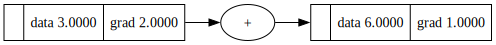

In [ ]:

# Value class with data, grad, _backward, _prev, _op
#  __add__ with _backward closure (gradient flows equally to both parents)
#  __mul__ with _backward (chain rule: each parent gets the other's data × out.grad)
#  __pow__ for scalar exponents
#  __neg__, __sub__, __truediv__, __radd__, __rmul__ (reverse ops for 2 * x)
#  tanh() method with _backward (derivative: 1 - tanh²)
class Value:
    def __init__(self, data, _children=(), op='', _label = ''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = op
        self.grad = 0.0
        self._label = _label

    def __repr__(self):
        return f"Value data={self.data}"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        new_value = Value(self.data + other.data, (self, other), "+")
        
        def _backward():
            self.grad += new_value.grad * 1
            other.grad += new_value.grad * 1
        
        new_value._backward = _backward
        return new_value

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        new_value = Value(self.data * other.data, (self, other), "*")
        
        def _backward():
            self.grad += new_value.grad * other.data
            other.grad += new_value.grad * self.data
        
        new_value._backward = _backward
        return new_value
    
    def tanh(self): 
        new_value = Value((math.exp(self.data*2)-1) / (math.exp(self.data*2) +1), (self,), "tanh")
        new_value.grad = 1

        def _backward():
            self.grad += (1 - new_value.data**2) * new_value.grad # chain

        new_value._backward = _backward
        return new_value
    
    def backward(self):
        self.grad = 1
        topoList = _build_topo(self)
        for val in reversed(topoList):
            val._backward()
    

def _build_topo(val):
    topo = []
    visited = set()

    def _build_topo(val):
        if val not in visited:
            visited.add(val)
            for child in val._prev:
                _build_topo(child)
            topo.append(val)
    
    _build_topo(val)

    return topo


def forward_pass():
    # forward 
    # a = Value(2, _label='a')
    # b = Value(0.52, _label='b')
    # c = Value(1.2, _label='c')
    # d = Value(-0.3, _label='d')
    # e = Value(-0.5, _label='e')

    # f = a * b
    # f._label="f"

    # g = c * d
    # g._label="g"

    # h = f + g
    # h._label="h"

    # L = h * e
    # L._label="L"

    # t = L.tanh(); t._label = "t"

    a = Value(3.0)
    b = a + a
    # b.backward()
    # assert a.grad == 2.0
    return b

out = forward_pass()
out.backward()
draw_dot(out)


[Value data=-0.5, Value data=2, Value data=0.52, Value data=1.04, Value data=1.2, Value data=-0.3, Value data=-0.36, Value data=0.68, Value data=-0.34, Value data=-0.3274773948087054]


[Value data=-0.5,
 Value data=2,
 Value data=0.52,
 Value data=1.04,
 Value data=1.2,
 Value data=-0.3,
 Value data=-0.36,
 Value data=0.68,
 Value data=-0.34,
 Value data=-0.3274773948087054]

In [111]:
# forward 
a = Value(2, _label='a')
b = Value(0.52, _label='b')
c = Value(1.2, _label='c')
d = Value(-0.3, _label='d')
e = Value(-0.5, _label='e')

f = a * b
f._label="f"

g = c * d
g._label="g"

h = f + g
h._label="h"

L = h * e
L._label="L"

t = L.tanh(); t._label = "t"

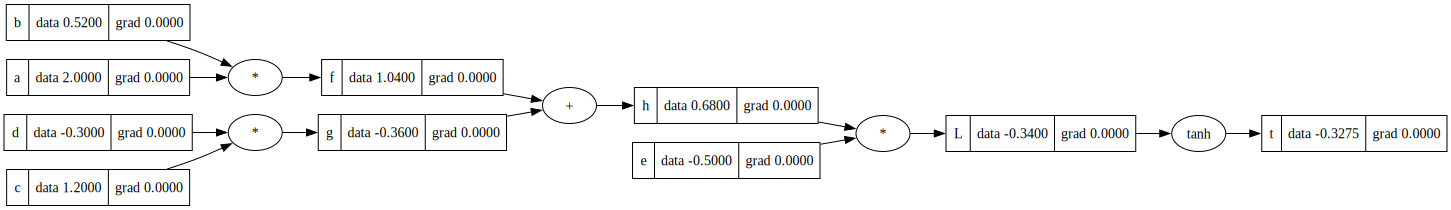

In [112]:
draw_dot(t)

In [ ]:
t.grad = 1
t._backward()

# grad_e = dL/de = h
# dL / de = h
L._backward()

# # e does not have _backward

# f, g
# grad f = dL/df = dL/dh * dh/df = 5 * (f + g)' = 5 * 1 = 5. => add is just copy the previous grad
h._backward()

# a, b
# grad a = dL/da = dL/dh * dh/df * df/da = -5 * b = -15
f._backward()
g._backward()


In [61]:
def gradchecking():
    # forward 
    a = Value(2, _label='a')
    b = Value(3, _label='b')
    c = Value(5, _label='c')
    d = Value(-2, _label='d')
    e = Value(-5, _label='e')

    f = a * b
    f._label="f"

    g = c * d
    g._label="g"

    h = f + g
    h._label="h"

    L1 = h * e
    L1._label="L"

    ee = Value(0.001)

    L2 = h * (e + ee)
    L2._label="L2"

    dd = (L2.data - L1.data) / ee.data
    print(dd)


gradchecking()

-4.000000000001336
